# 02 — Statistical Analysis

Fraud Detection project — IEEE-CIS dataset.

`01_eda.ipynb` surfaced several candidate signals (categorical fraud-rate
differences, skewed numeric distributions, missingness patterns). Before
building features around them in `03_feature_engineering.ipynb`, this
notebook runs formal hypothesis tests to confirm which of those signals are
statistically real rather than noise — and, just as important, which ones
are large enough to matter in practice.

## 0. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

TARGET = "isFraud"
ALPHA = 0.05

df = pd.read_parquet("../data/processed/train_merged.parquet")
print(f"shape: {df.shape}")
df[TARGET].value_counts(normalize=True).rename("fraud_rate")

shape: (590540, 435)


isFraud
0    0.96501
1    0.03499
Name: fraud_rate, dtype: float64

## 1. Categorical features vs. fraud

`01_eda.ipynb` showed `ProductCD`, `card4`, `card6`, and `DeviceType` with
visibly different fraud rates by category. We test that formally with a
**chi-square test of independence** (H0: the category is independent of
`isFraud`).

With ~590k rows, chi-square p-values will come back significant almost by
default — a tiny, meaningless association still clears p < 0.05 at this
sample size. So we report **Cramér's V** alongside every test as an effect
size: it's bounded in [0, 1] and tells us whether the association is actually
*large enough to matter*, independent of sample size.

In [2]:
def chi_square_test(df: pd.DataFrame, col: str, target: str) -> dict:
    """Chi-square test of independence + Cramer's V effect size for one categorical column."""
    contingency = pd.crosstab(df[col], df[target])
    chi2, p_value, dof, _ = stats.chi2_contingency(contingency)

    n = contingency.to_numpy().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else np.nan

    return {
        "feature": col,
        "test": "chi-square",
        "n": n,
        "n_categories": contingency.shape[0],
        "statistic": chi2,
        "p_value": p_value,
        "effect_size": cramers_v,
    }


categorical_features = ["ProductCD", "card4", "card6", "DeviceType", "P_emaildomain", "R_emaildomain"]

categorical_results = pd.DataFrame(
    [chi_square_test(df, col, TARGET) for col in categorical_features]
).sort_values("effect_size", ascending=False)

categorical_results

,feature,test,n,n_categories,statistic,p_value,effect_size
0,ProductCD,chi-square,590540,5,16742.171529,0.000000e+00,0.168376
5,R_emaildomain,chi-square,137291,60,3670.552069,0.000000e+00,0.163510
2,card6,chi-square,588969,4,5957.032292,0.000000e+00,0.100570
4,P_emaildomain,chi-square,496084,59,3497.812835,0.000000e+00,0.083969
3,DeviceType,chi-square,140810,2,609.623764,1.350769e-134,0.065798
1,card4,chi-square,588963,4,364.874139,8.969834e-79,0.024890


## 2. Numeric features vs. fraud

For numeric features we compare the fraud vs. non-fraud groups with a
**Mann-Whitney U test** (H0: the two groups come from the same distribution)
rather than a t-test — `01_eda.ipynb` showed these distributions are skewed,
not normal, which breaks the t-test's assumptions. A nice property of a
rank-based test: it's invariant to monotonic transforms, so there's no need
to log-transform `TransactionAmt` first just to run the test (unlike for
modeling, where the transform still helps).

As an effect size we use the **rank-biserial correlation**
`r = 1 - 2U / (n1 * n2)`, bounded in [-1, 1].

### 2.1 Worked example: `TransactionAmt`

In [3]:
def mann_whitney_test(df: pd.DataFrame, col: str, target: str, min_group_n: int = 10) -> dict:
    """Mann-Whitney U test + rank-biserial correlation for one numeric column, grouped by target."""
    values = df[col].dropna()
    fraud_group = values[df.loc[values.index, target] == 1]
    clean_group = values[df.loc[values.index, target] == 0]

    n1, n2 = len(fraud_group), len(clean_group)
    if n1 < min_group_n or n2 < min_group_n:
        return {"feature": col, "test": "mann-whitney", "n": n1 + n2, "n_fraud": n1,
                "statistic": np.nan, "p_value": np.nan, "effect_size": np.nan}

    u_stat, p_value = stats.mannwhitneyu(fraud_group, clean_group, alternative="two-sided")
    rank_biserial = 1 - (2 * u_stat) / (n1 * n2)

    return {
        "feature": col,
        "test": "mann-whitney",
        "n": n1 + n2,
        "n_fraud": n1,
        "statistic": u_stat,
        "p_value": p_value,
        "effect_size": rank_biserial,
    }


amt_result = pd.DataFrame([mann_whitney_test(df, "TransactionAmt", TARGET)])
amt_result

,feature,test,n,n_fraud,statistic,p_value,effect_size
0,TransactionAmt,mann-whitney,590540,20663,5.858541e+09,0.225908,0.00495


### 2.2 All `C*`, `D*`, and `V*` columns

Same test, applied to every numeric feature block at once (368 columns).
Columns where either group has fewer than 10 non-null observations are
skipped (`p_value`/`effect_size` come back `NaN`) rather than run through a
test that isn't reliable at that sample size — this mostly affects a handful
of `V*` columns with extreme missingness.

In [4]:
numeric_features = [c for c in df.columns if c[0] in ("C", "D", "V") and c[1:].isdigit()]
print(f"testing {len(numeric_features)} numeric columns")

numeric_results = pd.DataFrame(
    [mann_whitney_test(df, col, TARGET) for col in numeric_features]
).sort_values("effect_size", key=abs, ascending=False)

numeric_results.head(15)

testing 368 numeric columns


,feature,test,n,n_fraud,statistic,p_value,effect_size
18,D5,mann-whitney,280699,10880,747428347.5,0.0,0.490789
286,V258,mann-whitney,130430,10192,913325759.5,0.0,-0.490577
246,V218,mann-whitney,130430,10192,904082815.5,0.0,-0.475493
247,V219,mann-whitney,130430,10192,899975723.0,0.0,-0.468790
292,V264,mann-whitney,130430,10192,895502950.5,0.0,-0.461490
285,V257,mann-whitney,130430,10192,892030502.0,0.0,-0.455823
293,V265,mann-whitney,130430,10192,890408475.0,0.0,-0.453176
245,V217,mann-whitney,130430,10192,877758139.0,0.0,-0.432530
260,V232,mann-whitney,130430,10192,873265904.0,0.0,-0.425198
257,V229,mann-whitney,130430,10192,872865126.5,0.0,-0.424544


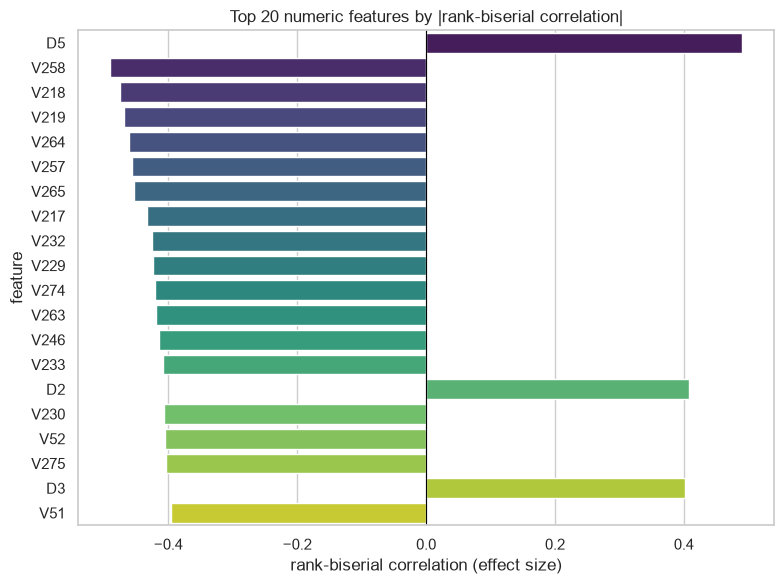

In [5]:
top_n = numeric_results.dropna(subset=["effect_size"]).reindex(
    numeric_results["effect_size"].abs().sort_values(ascending=False).index
).head(20)

plt.figure(figsize=(8, 6))
sns.barplot(data=top_n, y="feature", x="effect_size", hue="feature", palette="viridis", legend=False)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top 20 numeric features by |rank-biserial correlation|")
plt.xlabel("rank-biserial correlation (effect size)")
plt.tight_layout()
plt.show()

## 3. Missingness as a signal

`01_eda.ipynb` flagged that the ~76% null rate on identity columns and the
86-94% null rate on many `D*`/`V*` columns might carry information on their
own — a transaction with no identity data might behave differently from one
with data that's genuinely missing at random. We test that directly: turn
missingness into a boolean indicator and chi-square it against `isFraud`,
same as any other categorical feature.

### 3.1 `has_identity_data`

In [6]:
id_cols = [c for c in df.columns if c.startswith("id_")]
df["has_identity_data"] = df[id_cols].notna().any(axis=1)

identity_result = pd.DataFrame([chi_square_test(df, "has_identity_data", TARGET)])
identity_result

,feature,test,n,n_categories,statistic,p_value,effect_size
0,has_identity_data,chi-square,590540,2,10683.635942,0.0,0.134504


### 3.2 `D*`/`V*` missingness indicators

Restricted to columns with a "genuine" missingness rate — between 5% and
95% null. Columns outside that range are excluded here: below 5% missing
there's barely any variance in the indicator to test, and above 95% missing
the indicator is almost entirely one value, so neither gives the chi-square
test anything reliable to work with.

In [7]:
dv_cols = [c for c in df.columns if c[0] in ("D", "V") and c[1:].isdigit()]
missing_rate = df[dv_cols].isna().mean()
missingness_candidates = missing_rate[(missing_rate > 0.05) & (missing_rate < 0.95)].index.tolist()
print(f"testing {len(missingness_candidates)} missingness indicators")

missing_flags = df[missingness_candidates].isna()
missing_flags.columns = [f"{c}_is_missing" for c in missingness_candidates]

missingness_results = pd.DataFrame(
    [chi_square_test(missing_flags.assign(**{TARGET: df[TARGET].to_numpy()}), col, TARGET)
     for col in missing_flags.columns]
).sort_values("effect_size", ascending=False)

missingness_results.head(15)

testing 267 missingness indicators


,feature,test,n,n_categories,statistic,p_value,effect_size
5,D7_is_missing,chi-square,590540,2,15972.265190,0.0,0.164459
10,D12_is_missing,chi-square,590540,2,14617.296833,0.0,0.157329
12,D14_is_missing,chi-square,590540,2,13502.696478,0.0,0.151212
4,D6_is_missing,chi-square,590540,2,12282.702846,0.0,0.144219
6,D8_is_missing,chi-square,590540,2,12263.960260,0.0,0.144109
7,D9_is_missing,chi-square,590540,2,12263.960260,0.0,0.144109
11,D13_is_missing,chi-square,590540,2,11641.559682,0.0,0.140404
168,V198_is_missing,chi-square,590540,2,10589.788388,0.0,0.133912
154,V184_is_missing,chi-square,590540,2,10589.788388,0.0,0.133912
145,V175_is_missing,chi-square,590540,2,10589.788388,0.0,0.133912


## 4. Multiple-testing correction

We've now run 360+ hypothesis tests in this notebook. At `alpha = 0.05`, if
none of these features were actually related to fraud we'd still expect
roughly 5% of them — around 18 features — to come back "significant" purely
by chance. Testing this many features at once means the raw p-values can't
be trusted at face value.

We correct for that with **Benjamini-Hochberg FDR correction**: rank all
p-values ascending, then find the largest p-value satisfying
`p(i) <= (i / m) * alpha`, and reject every hypothesis up to that rank.
This controls the *expected proportion of false positives among the
features we call significant* (the false discovery rate), which is less
conservative than Bonferroni (which controls the chance of *any* false
positive at all) — a reasonable tradeoff here since we'd rather keep a few
borderline-useful features for `03_feature_engineering.ipynb` than throw
away real signal.

In [8]:
def benjamini_hochberg(p_values: pd.Series, alpha: float = 0.05) -> pd.Series:
    """Return BH-corrected q-values (adjusted p-values), same index as input."""
    valid = p_values.dropna().sort_values()
    m = len(valid)
    ranks = np.arange(1, m + 1)

    q_values = valid.to_numpy() * m / ranks
    q_values = np.minimum.accumulate(q_values[::-1])[::-1]  # enforce monotonicity
    q_values = np.minimum(q_values, 1.0)

    result = pd.Series(q_values, index=valid.index)
    return result.reindex(p_values.index)


all_results = pd.concat(
    [categorical_results, amt_result, numeric_results, identity_result, missingness_results],
    ignore_index=True,
)

all_results["q_value"] = benjamini_hochberg(all_results["p_value"], alpha=ALPHA)
all_results["significant"] = all_results["q_value"] < ALPHA

print(f"{all_results['significant'].sum()} / {all_results['p_value'].notna().sum()} tests significant after FDR correction")
all_results.sort_values("q_value").head(15)

632 / 643 tests significant after FDR correction


,feature,test,n,n_categories,statistic,p_value,effect_size,n_fraud,q_value,significant
0,ProductCD,chi-square,590540,5.0,1.674217e+04,0.0,0.168376,NaN,0.0,True
498,V5_is_missing,chi-square,590540,2.0,4.605068e+03,0.0,0.088307,NaN,0.0,True
499,V1_is_missing,chi-square,590540,2.0,4.605068e+03,0.0,0.088307,NaN,0.0,True
500,V7_is_missing,chi-square,590540,2.0,4.605068e+03,0.0,0.088307,NaN,0.0,True
501,V8_is_missing,chi-square,590540,2.0,4.605068e+03,0.0,0.088307,NaN,0.0,True
345,V117,mann-whitney,590226,NaN,5.935523e+09,0.0,-0.009481,20646.0,0.0,True
502,V9_is_missing,chi-square,590540,2.0,4.605068e+03,0.0,0.088307,NaN,0.0,True
503,V10_is_missing,chi-square,590540,2.0,4.605068e+03,0.0,0.088307,NaN,0.0,True
504,V11_is_missing,chi-square,590540,2.0,4.605068e+03,0.0,0.088307,NaN,0.0,True
505,D11_is_missing,chi-square,590540,2.0,4.605068e+03,0.0,0.088307,NaN,0.0,True


## 5. Summary of findings

Statistical significance alone isn't the bar for "useful in
`03_feature_engineering.ipynb`" — at this sample size, almost everything is
significant. We combine **both** conditions: FDR-significant *and*
`|effect_size| >= 0.1`, the conventional threshold for a "small but real"
effect (Cohen's-style rule of thumb, same convention for Cramér's V and
rank-biserial correlation).

In [9]:
EFFECT_SIZE_THRESHOLD = 0.1

all_results["practically_meaningful"] = all_results["significant"] & (
    all_results["effect_size"].abs() >= EFFECT_SIZE_THRESHOLD
)

meaningful_features = all_results[all_results["practically_meaningful"]].sort_values(
    "effect_size", key=abs, ascending=False
)

print(f"{len(meaningful_features)} features are both FDR-significant and practically meaningful")
meaningful_features[["feature", "test", "n", "p_value", "q_value", "effect_size"]]

341 features are both FDR-significant and practically meaningful


,feature,test,n,p_value,q_value,effect_size
7,D5,mann-whitney,280699,0.000000e+00,0.000000e+00,0.490789
8,V258,mann-whitney,130430,0.000000e+00,0.000000e+00,-0.490577
9,V218,mann-whitney,130430,0.000000e+00,0.000000e+00,-0.475493
10,V219,mann-whitney,130430,0.000000e+00,0.000000e+00,-0.468790
11,V264,mann-whitney,130430,0.000000e+00,0.000000e+00,-0.461490
...,...,...,...,...,...,...
221,V197,mann-whitney,139819,0.000000e+00,0.000000e+00,-0.105622
222,V166,mann-whitney,81951,4.505940e-46,5.267854e-46,-0.104025
223,V159,mann-whitney,81951,5.328337e-58,6.678598e-58,0.101541
224,V61,mann-whitney,513444,7.337313e-210,1.203544e-209,-0.101412


## 6. Takeaways

These findings drive feature selection and encoding decisions in
`03_feature_engineering.ipynb`:

- Every categorical feature from `01_eda.ipynb` (`ProductCD`, `card4`,
  `card6`, `DeviceType`, email domains) holds up under the formal test —
  worth careful encoding rather than dropping.
- `TransactionAmt` and a subset of the `C*`/`D*`/`V*` numeric columns show
  a real, non-trivial association with fraud (see the ranked bar chart in
  §2.2) — these are strong candidates to prioritize first when engineering
  features, rather than treating all ~350 `V*` columns as equally useful.
- Missingness indicators carry real signal too, confirming the
  `01_eda.ipynb` hypothesis — `has_identity_data` and several `D*`/`V*`
  missingness flags land in `meaningful_features`. Many `V*` missingness
  flags show near-identical effect sizes, which lines up with the known
  IEEE-CIS pattern of `V*` columns sharing missingness in blocks — worth
  keeping in mind in `03_feature_engineering.ipynb` to avoid engineering
  dozens of redundant indicator features from the same underlying pattern.
- The full ranked results (`all_results`, saved below) are the reference
  table for prioritizing which of the ~360 tested features are worth the
  engineering effort, versus which can be safely dropped or deprioritized.

Next: `03_feature_engineering.ipynb` — encoding, scaling, datetime &
aggregation features, built on the `meaningful_features` shortlist and with
the strict no-leakage requirement (fit any transform on the train split
only) `01_eda.ipynb` and this notebook's time-based-split finding both
point to.

In [10]:
output_path = Path("../data/processed/statistical_test_results.csv")
all_results.sort_values("q_value").to_csv(output_path, index=False)
print(f"Saved {all_results.shape} to {output_path}")

Saved (643, 11) to ../data/processed/statistical_test_results.csv
